# Grammar Scoring Engine — Final Submission (E028)

Predict a continuous grammar score for 45–60 s spoken English recordings.

**Final model:** a calibrated blend of three channels.

1. **Text** (35%): an equal-weight ensemble of fine-tuned DeBERTa-v3 regressors that read
   default Whisper, disfluency-preserving ("verbatim") Whisper and literal wav2vec2 CTC
   transcripts.
2. **Audio** (25%): Ridge regressions on frozen WavLM-large and Whisper-encoder states, for
   what transcripts lose: pronunciation, rhythm, pauses.
3. **Audio language model** (40%): Ridge regressions on hidden states of Voxtral-Mini-3B,
   which listens to the clip together with a question about the speaker's grammar.

**Validation is the main lesson of this project.** Speakers repeat in the training set and are
mostly new in the test set, and the test set is mostly short clips from single-clip speakers.
Every model here is validated on **speakers it never heard**, and headline numbers are weighted
to the **test set's mix** of recordings.

| Metric on the training data (732 clips, every clip scored by models that never heard its speaker) | Value |
| --- | ---: |
| **RMSE at the test-like mix (honest estimate)** | computed below — 0.536 |
| RMSE / Pearson, unweighted | computed below — 0.521 / 0.859 |
| Public leaderboard | 0.3341 |

This notebook is the report: approach, preprocessing, architecture, evaluation and charts. It
recomputes every number from stored predictions and frozen features (produced once on GPU with
the package code referenced below), refits the small Ridge models, and writes the 216-row
`submission.csv`. It runs on CPU in about a minute.

## 1. Approach in one paragraph

Grammar is a property of *what was said*, so the core is **audio → transcript → text
regressor**. Default Whisper output is too clean for grammar scoring (it drops fillers and
quietly fixes errors: "I liked *to* playground" → "I liked *the* playground"), so the text
models also read verbatim and CTC transcripts that keep the errors. Raters also hear fluency
and pronunciation, so two audio channels are added from frozen speech models. Because 732
clips are far too few to train speech models, the large models stay frozen and only small
Ridge regressors learn from their states. All cross-validation folds keep each speaker's clips
together, and blend weights and a final linear calibration are fitted on those unseen-speaker
predictions.

```text
                ┌─ Whisper large-v3 (default)          → canonical ─┐
                ├─ Whisper large-v3 + disfluent prompt → verbatim v1 ┼─ 6 DeBERTa-v3 groups ─ mean ─► text
audio (.wav) ───┤  Whisper large-v3 + per-window cue   → verbatim v2 │   (large/base × dual/v2/CTC)
                ├─ wav2vec2-large CTC, no LM           → literal CTC ┘
                ├─ WavLM-large layer 20 ───────────── Ridge ─┐
                ├─ Whisper encoder layers 22–32 ───── Ridge ─┴─ mean ──────────────────────────► audio
                └─ Voxtral-Mini-3B, layers 12–14, three views ── Ridge each ── mean ───────────► voxtral

        score = clip(−0.385 + 1.099 × (0.35 × text + 0.25 × audio + 0.40 × voxtral), 1, 5)
```

## 2. Setup

Paths resolve automatically for a local checkout (run from `notebooks/`) or a Kaggle notebook
with the competition data and the private artifact dataset
`lijoraju94/grammar-scoring-e015-final-artifacts` attached. All reusable logic is imported
from the `grammar_scoring` package in this repository.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:
    REPO = Path("/kaggle/working/grammar-scoring")
    if not REPO.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "https://github.com/lijoraju/grammar-scoring.git",
                str(REPO),
            ],
            check=True,
        )
    DATA_DIR = next(Path("/kaggle/input").glob("**/Dataset_Final/train.csv")).parent
    FINAL_DIR = next(
        Path("/kaggle/input").glob("**/grammar-scoring-e015-final-artifacts*")
    )
    CANON_DIR = next(
        Path("/kaggle/input").glob("**/grammar-scoring-canonical-artifacts*")
    )
    OUTPUT_DIR = Path("/kaggle/working")
else:
    REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
    DATA_DIR = REPO / "data/raw/Dataset_Final"
    FINAL_DIR = REPO / "artifacts/final_e015"
    CANON_DIR = REPO / "artifacts/transcripts"
    OUTPUT_DIR = REPO / "artifacts/final_e015"
sys.path.insert(0, str(REPO / "src"))
print("data:", DATA_DIR, "| artifacts:", FINAL_DIR)

data: /Volumes/Transcend/Kaggle Competition/grammar-scoring/data/raw/Dataset_Final | artifacts: /Volumes/Transcend/Kaggle Competition/grammar-scoring/artifacts/final_e015


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from grammar_scoring.evaluation.metrics import regression_metrics
from grammar_scoring.experiments.e014_ensemble import ensemble_report, load_groups
from grammar_scoring.experiments.e014_finetune import load_transcripts
from grammar_scoring.experiments.e027_honest_blend import (
    AUDIO_ALPHA,
    AUDIO_FEATURES,
    SHORT_SECONDS,
    VOXTRAL_ALPHA,
    apply_calibration,
    best_weights,
    fit_calibration,
    load_features,
    speaker_groups,
    unseen_speaker_mask,
    weighted_rmse,
)
from grammar_scoring.experiments.e028_grouped_blend import (
    CHANNELS,
    VOXTRAL_VIEWS,
    cell_weights,
    has_partner,
    nested_blend,
    ridge_channel,
)
from grammar_scoring.features.disfluency import text_features

# Validated categorical palette (fixed order) and recessive ink for axes and text.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED, SURFACE = "#0b0b0b", "#898781", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
    }
)

## 3. Data and preprocessing

* **Rows:** 769 training and 216 test recordings (WAV, 45–60 s). Labels are MOS Likert grammar
  scores in half-point steps.
* **Zero-label block (excluded):** 37 training rows labelled 0, all from one contiguous file
  block (`audio_5037`–`audio_5073`) with heavy background noise and otherwise fluent speech.
  They behave like a different source (they contributed ~43% of squared error in early
  models) and no test file comes from that block, so the final population keeps the
  **732 rows with label > 0**. Filenames are only diagnostic; they are never features.
* **Folds:** five frozen folds created once and reused by every experiment, so all OOF
  numbers are comparable. Validation folds never influence training, checkpoint weights or
  test predictions of their own fold.
* **Audio preprocessing:** Whisper resamples to 16 kHz mono internally; no VAD, no denoising
  and no text normalization are applied, so disfluencies survive into the transcripts.

train rows: 769 | test rows: 216 | zero labels: 37


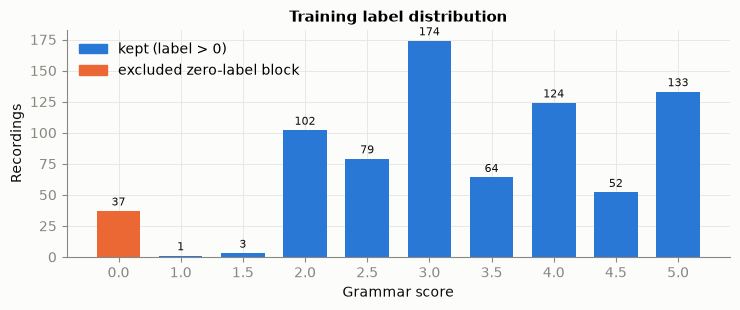

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
n_zero = int((train.label == 0).sum())
print(f"train rows: {len(train)} | test rows: {len(test)} | zero labels: {n_zero}")

counts = train.label.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.5, 3.2))
colors = [ORANGE if label == 0 else BLUE for label in counts.index]
bars = ax.bar(counts.index.astype(str), counts.values, color=colors, width=0.7)
ax.bar_label(bars, padding=2, color=INK, fontsize=8)
ax.set(title="Training label distribution", xlabel="Grammar score", ylabel="Recordings")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=BLUE),
        plt.Rectangle((0, 0), 1, 1, color=ORANGE),
    ],
    labels=["kept (label > 0)", "excluded zero-label block"],
    frameon=False,
)
plt.tight_layout()
plt.show()

## 4. ASR: why verbatim transcripts matter

Whisper transcripts come from **faster-whisper large-v3** (English, beam 5, no VAD); the CTC
transcript comes from **wav2vec2-large-960h-lv60-self** with greedy decoding:

| Transcript | Decoding | Purpose |
| --- | --- | --- |
| canonical | default settings, no prompt | clean, well-punctuated text |
| verbatim v1 | disfluent `initial_prompt`, conditioned on previous text | keep fillers, false starts and errors |
| verbatim v2 | disfluent style cue re-inserted in **every** 30 s window, no text conditioning, stricter compression-ratio fallback | same goal, without v1's rare repetition loops / prompt leakage |
| CTC | wav2vec2 frame-level characters, greedy, 20 s chunks with 4 s overlap; lower-case, no punctuation | fully literal: no language model to repair errors |

Code: `src/grammar_scoring/transcription/verbatim.py` (variants `v1`, `v2`) and
`src/grammar_scoring/transcription/ctc.py`. CTC adds literal *words* ("i like to playground",
"a lot kids") rather than fillers, which its read-speech training data lacks. It heard no speech in 17 of the 37
excluded zero-label clips, independent support for treating that block as noisy audio.

In [4]:
versions = {
    "canonical": CANON_DIR,
    "verbatim v1": FINAL_DIR / "transcripts_verbatim_v1",
    "verbatim v2": FINAL_DIR / "transcripts_verbatim_v2",
    "CTC": FINAL_DIR / "transcripts_ctc",
}
texts = {
    name: load_transcripts(path / "train.jsonl") for name, path in versions.items()
}
example = "audio_61.wav"
print(f"{example} — label {train.set_index('filename').label[example]}\n")
for name, mapping in texts.items():
    print(f"[{name}]\n{mapping[example][:330]}…\n")

audio_61.wav — label 2.0

[canonical]
Well, when I was a child, I remember I went to the kindergarten, and I liked the playground. I remember there are a lot of kids, a lot, well, the teacher, and just enjoy your life. didn't think in other those it was so good because you need just enjoy enjoy play play play with the with the land play with the cars or play video g…

[verbatim v1]
Well, when I was a child, I remember I went to the kindergarten and I liked to playground. I remember there are a lot kids, a lot, well, the teacher, um, just enjoy your life. You didn't think in other those, uh, it was so good because you need just enjoy, enjoy, play, play, play with the- with the land, play with the cars, or, …

[verbatim v2]
Well, when I was a child, I remember I went to the kindergarten and I liked the playground. I remember there are a lot kids, a lot, well, the teacher, and just enjoy your life. didn't think in other those, uh, it was so good because you need just enjoy, enjoy, play, p

,canonical,verbatim v1,verbatim v2,CTC
disf_filler_rate,0.34,4.06,3.76,0.24
disf_false_start_rate,0.00,1.86,1.49,0.00


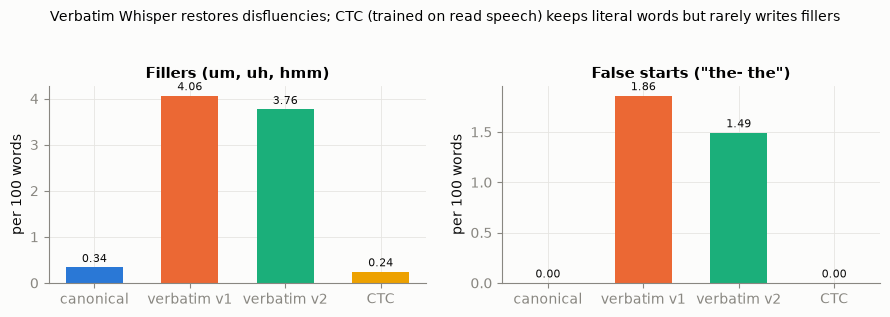

In [5]:
# Disfluency rates per 100 words from the package feature code (labels unused).
canonical = texts["canonical"]
rates = (
    pd.DataFrame(
        {
            name: pd.DataFrame(
                [text_features(canonical[k], mapping[k]) for k in canonical]
            ).mean()
            for name, mapping in texts.items()
        }
    ).loc[["disf_filler_rate", "disf_false_start_rate"]]
    * 100
)
display(rates.round(2))

panels = [
    ("disf_filler_rate", "Fillers (um, uh, hmm)"),
    ("disf_false_start_rate", 'False starts ("the- the")'),
]
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, (metric, title) in zip(axes, panels, strict=True):
    bars = ax.bar(
        rates.columns, rates.loc[metric], color=[BLUE, ORANGE, AQUA, YELLOW], width=0.6
    )
    ax.bar_label(bars, fmt="%.2f", padding=2, color=INK, fontsize=8)
    ax.set(title=title, ylabel="per 100 words")
fig.suptitle(
    "Verbatim Whisper restores disfluencies; CTC (trained on read speech) "
    "keeps literal words but rarely writes fillers",
    y=1.04,
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 5. Model architecture and training

Implemented in `src/grammar_scoring/experiments/e014_finetune.py`:

* **Backbone:** `microsoft/deberta-v3-large` (435M) or `deberta-v3-base` (184M), fully
  fine-tuned; encoder dropout disabled (it hurts regression targets).
* **Head:** attention-mask-aware mean pooling → linear layer; head bias initialised to the
  training-fold mean label.
* **Loss / optimiser:** MSE; AdamW (weight decay 0.01), linear warm-up (10%) and decay,
  5 epochs, effective batch 16, fp16 autocast, max 320 tokens. Large: lr 1e-5 with layer-wise
  LR decay 0.9; base: lr 2e-5. Head lr 1e-3.
* **Dual-transcript training:** every training clip contributes two examples (canonical and
  verbatim v1, same label); validation/test predictions average the two texts.
* **Model selection:** per fold, the epoch with the best validation RMSE (same rule as all
  earlier experiments); its test predictions are kept and averaged over the five folds.
* **Seeds:** 42, 7, 2024 (fixed and recorded per run).
* **Folds:** the final text models use five **speaker-grouped** folds (stratified by score):
  all clips of a speaker are in one fold, so each model is validated, and its epoch selected,
  on speakers it never heard (`--folds-csv`).

In [6]:
GROUPS = {
    "large_dual": "DeBERTa-large · canonical + verbatim v1",
    "base_dual": "DeBERTa-base · canonical + verbatim v1",
    "large_v2": "DeBERTa-large · verbatim v2",
    "base_v2": "DeBERTa-base · verbatim v2",
    "large_ctc": "DeBERTa-large · CTC",
    "base_ctc": "DeBERTa-base · CTC",
}
run_dirs = {g: sorted((FINAL_DIR / "runs_grouped" / g).iterdir()) for g in GROUPS}
rows = []
for group, dirs in run_dirs.items():
    for d in dirs:
        r = json.loads((d / "result.json").read_text())
        rows.append(
            {
                "group": group,
                "run": r["run_name"],
                "seed": r["config"]["seed"],
                "OOF RMSE": r["oof_rmse"],
                "OOF Pearson": r["oof_pearson"],
                "GPU": r["device"],
                "minutes": r["minutes"],
            }
        )
runs_table = pd.DataFrame(rows)
display(runs_table.round(4))

,group,run,seed,OOF RMSE,OOF Pearson,GPU,minutes
0,large_dual,deberta-v3-large_dual_lr1e-05_s2024,2024,0.5869,0.8170,Tesla T4,38.4015
1,large_dual,deberta-v3-large_dual_lr1e-05_s42,42,0.5797,0.8226,Tesla T4,39.2520
2,large_dual,deberta-v3-large_dual_lr1e-05_s7,7,0.5793,0.8207,Tesla T4,38.4695
3,base_dual,deberta-v3-base_dual_lr2e-05_s2024,2024,0.5937,0.8107,Tesla T4,11.1327
4,base_dual,deberta-v3-base_dual_lr2e-05_s42,42,0.5832,0.8182,Tesla T4,11.8745
5,base_dual,deberta-v3-base_dual_lr2e-05_s7,7,0.5965,0.8086,Tesla T4,11.1404
6,large_v2,deberta-v3-large_lr1e-05_s42,42,0.5855,0.8186,Tesla T4,18.9297
7,large_v2,deberta-v3-large_lr1e-05_s7,7,0.5815,0.8203,Tesla T4,18.8329
8,base_v2,deberta-v3-base_lr2e-05_s42,42,0.6012,0.8077,Tesla T4,5.5286
9,base_v2,deberta-v3-base_lr2e-05_s7,7,0.5875,0.8150,Tesla T4,5.5202


## 6. Text ensemble (speaker-grouped out-of-fold predictions)

Row *i* in fold *k* is predicted by the fold-*k* model, trained on the other four folds, which
contain none of that row's speaker. Seeds are averaged inside each group and the six groups
with equal weight.

In [7]:
oof, test_pred = load_groups(run_dirs)
report = ensemble_report(oof, list(GROUPS))
summary = pd.DataFrame(
    [{"model": GROUPS[g], "runs": len(run_dirs[g]), **report[g]} for g in GROUPS]
    + [
        {
            "model": "TEXT ENSEMBLE: equal-weight mean of the 6 groups",
            "runs": sum(map(len, run_dirs.values())),
            **report["mean"],
        }
    ]
).rename(columns={"rmse": "RMSE", "pearson_correlation": "Pearson"})
display(summary.round(4))
text_oof = oof[list(GROUPS)].mean(axis=1).to_numpy()
text_test = test_pred[list(GROUPS)].mean(axis=1).to_numpy()
y = oof["label"].to_numpy()
folds = oof["fold"].to_numpy()

,model,runs,RMSE,Pearson
0,DeBERTa-large · canonical + verbatim v1,3,0.5698,0.8273
1,DeBERTa-base · canonical + verbatim v1,3,0.5835,0.8179
2,DeBERTa-large · verbatim v2,2,0.5732,0.8257
3,DeBERTa-base · verbatim v2,2,0.5815,0.8200
4,DeBERTa-large · CTC,2,0.5952,0.8101
5,DeBERTa-base · CTC,2,0.6065,0.8014
6,TEXT ENSEMBLE: equal-weight mean of the 6 groups,14,0.5499,0.8413


## 7. Validating the way the test set is built

Two properties of the data, both found by checking the models' errors rather than averages:

* **Speakers repeat.** Clips are grouped into speakers by voice similarity (x-vectors from
  `microsoft/wavlm-base-plus-sv`, centred, cosine > 0.93, connected components;
  `e027_honest_blend.speaker_groups`). Most training clips have another clip by the same
  speaker with almost the same score, but few test clips match a training speaker. A model
  validated on random folds can look good by recognizing voices: an early audio model
  (RBF-SVR on the last WavLM layer) scored 0.50 RMSE on speakers it had heard and 0.73 on new
  ones. All folds here therefore keep a speaker's clips together.
* **The test mix differs.** Most test clips are shorter than 50 s and come from speakers with
  a single clip; in the training set that combination is rare. Single-clip speakers are
  harder to score whichever way the model is trained.

Reported numbers are therefore weighted so that the four combinations of (short / long) ×
(single-clip speaker / speaker with several clips) have their **test-set shares**.

speakers found: 377 for 732 training clips
score spread within a speaker: 0.19 (overall 1.01)
test clips matching a training speaker: 13%


,training set,test set
short clips (< 50 s),24%,69%
speaker has another clip in the set,69%,29%
short clip from a single-clip speaker,18%,62%


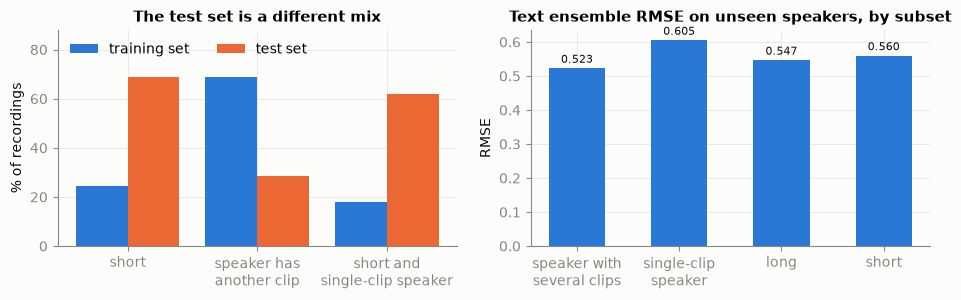

In [8]:
data = load_features(FINAL_DIR / "features_e028.npz")
train_index = {name: i for i, name in enumerate(data["train_filenames"])}
test_index = {name: i for i, name in enumerate(data["test_filenames"])}
rows = np.array([train_index[name] for name in oof["filename"]])
test_rows = np.array([test_index[name] for name in test_pred["filename"]])

# Speaker groups in sorted-filename order (deterministic group ids).
all_speakers = np.vstack([data["speaker_train"], data["speaker_test"]])
order = np.argsort(data["train_filenames"])
all_groups = np.empty(len(order), dtype=np.int64)
all_groups[order] = speaker_groups(data["speaker_train"][order], all_speakers)
groups = all_groups[rows]
assert pd.DataFrame({"g": groups, "f": folds}).groupby("g")["f"].nunique().max() == 1

short = data["duration_train"][rows] < SHORT_SECONDS
test_short = data["duration_test"][test_rows] < SHORT_SECONDS
partner = pd.Series(groups).map(pd.Series(groups).value_counts()).to_numpy() > 1
test_partner = has_partner(data["speaker_test"][test_rows], all_speakers)
weights = cell_weights(2 * short + partner, 2 * test_short + test_partner)

within = pd.Series(y[partner]).groupby(groups[partner]).std(ddof=0).mean()
centre = all_speakers.mean(axis=0)
unit = lambda e: (e - centre) / np.linalg.norm(e - centre, axis=1, keepdims=True)  # noqa: E731
match = (unit(data["speaker_test"]) @ unit(data["speaker_train"]).T).max(axis=1) > 0.93
print(f"speakers found: {len(np.unique(groups))} for {len(y)} training clips")
print(f"score spread within a speaker: {within:.2f} (overall {y.std():.2f})")
print(f"test clips matching a training speaker: {match.mean():.0%}")
mix = pd.DataFrame(
    {
        "training set": [short.mean(), partner.mean(), (short & ~partner).mean()],
        "test set": [
            test_short.mean(),
            test_partner.mean(),
            (test_short & ~test_partner).mean(),
        ],
    },
    index=[
        "short clips (< 50 s)",
        "speaker has another clip in the set",
        "short clip from a single-clip speaker",
    ],
)
display((mix * 100).round(0).astype(int).astype(str) + "%")

rmse = lambda p, m: regression_metrics(y[m], p[m])["rmse"]  # noqa: E731
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.1))
x = np.arange(len(mix))
axes[0].bar(
    x - 0.2, mix["training set"] * 100, width=0.4, color=BLUE, label="training set"
)
axes[0].bar(x + 0.2, mix["test set"] * 100, width=0.4, color=ORANGE, label="test set")
axes[0].set_xticks(
    x, ["short", "speaker has\nanother clip", "short and\nsingle-clip speaker"]
)
axes[0].set(title="The test set is a different mix", ylabel="% of recordings")
axes[0].set_ylim(0, 88)
axes[0].legend(frameon=False, ncol=2, loc="upper left")
subsets = {
    "speaker with\nseveral clips": partner,
    "single-clip\nspeaker": ~partner,
    "long": ~short,
    "short": short,
}
bars = axes[1].bar(
    list(subsets), [rmse(text_oof, m) for m in subsets.values()], color=BLUE, width=0.55
)
axes[1].bar_label(bars, fmt="%.3f", padding=2, color=INK, fontsize=8)
axes[1].set(title="Text ensemble RMSE on unseen speakers, by subset", ylabel="RMSE")
plt.tight_layout()
plt.show()

**Did the text models rely on recognizing speakers?** Barely. The cell below compares the
earlier text models, trained on random folds, with the final speaker-grouped ones on the same
rows. On rows whose speaker was also in the random training folds, holding speakers out costs
well under 0.01 RMSE; the large gap between the two row groups is there either way, because
those rows are mostly single-clip speakers, which are harder.

In [9]:
old_runs = {g: sorted((FINAL_DIR / "runs" / g).iterdir()) for g in GROUPS}
old_oof, _ = load_groups(old_runs)
assert old_oof["filename"].equals(oof["filename"])
old_text = old_oof[list(GROUPS)].mean(axis=1).to_numpy()
seen_before = ~unseen_speaker_mask(groups, old_oof["fold"].to_numpy())
display(
    pd.DataFrame(
        [
            {
                "rows": name,
                "n": int(m.sum()),
                "random-fold text models": rmse(old_text, m),
                "speaker-grouped text models": rmse(text_oof, m),
            }
            for name, m in [
                ("speaker was also in the random training folds", seen_before),
                ("speaker was not in the random training folds", ~seen_before),
                ("all", np.ones(len(y), dtype=bool)),
            ]
        ]
    ).round(4)
)

,rows,n,random-fold text models,speaker-grouped text models
0,speaker was also in the random training folds,477,0.5213,0.5258
1,speaker was not in the random training folds,255,0.5909,0.5922
2,all,732,0.5466,0.5499


## 8. Audio channels

Frozen features, extracted once on GPU (`features/audio_layers.py`,
`features/speaker_voxtral.py`), each averaged over time; a standardized Ridge is fitted inside
each speaker-grouped training fold:

| Channel | Frozen model and states | Regressor |
| --- | --- | --- |
| audio | WavLM-large hidden layer 20; Whisper large-v3 encoder layers 22–32 (two models, averaged) | Ridge, α = 1000 |
| voxtral | Voxtral-Mini-3B LLM layers 12–14 at the audio-token positions, three views averaged: audio before the question, and the questions "How accurate and complex is the speaker's grammar?" and "What grammatical errors does the speaker make?" placed before the audio | Ridge, α = 3000 |

Voxtral reads left to right, so its audio states depend on the question only when the question
comes first; three questions *after* the audio gave bit-identical features. The state of the
final token (which has seen audio and question) was clearly worse (≈ 0.60) and is not used.

In [10]:
audio_oof, audio_test = ridge_channel(
    data, AUDIO_FEATURES, rows, test_rows, y, folds, AUDIO_ALPHA
)
voxtral_oof, voxtral_test = ridge_channel(
    data, VOXTRAL_VIEWS, rows, test_rows, y, folds, VOXTRAL_ALPHA
)
channels = np.column_stack([text_oof, audio_oof, voxtral_oof])
test_channels = np.column_stack([text_test, audio_test, voxtral_test])

display(
    pd.DataFrame(
        [
            {
                "channel": name,
                "RMSE at the test-like mix": weighted_rmse(y, channels[:, i], weights),
                "RMSE unweighted": rmse(channels[:, i], slice(None)),
                "short clips": rmse(channels[:, i], short),
                "long clips": rmse(channels[:, i], ~short),
            }
            for i, name in enumerate(CHANNELS)
        ]
    ).round(4)
)
print("correlation between channels:")
display(
    pd.DataFrame(np.corrcoef(channels.T), index=CHANNELS, columns=CHANNELS).round(3)
)

,channel,RMSE at the test-like mix,RMSE unweighted,short clips,long clips
0,text,0.5736,0.5499,0.5598,0.5466
1,audio,0.6028,0.5753,0.6186,0.5607
2,voxtral,0.5603,0.5549,0.5543,0.5551


correlation between channels:


,text,audio,voxtral
text,1.000,0.876,0.933
audio,0.876,1.000,0.912
voxtral,0.933,0.912,1.000


## 9. Blend, calibration and the training RMSE

* **Blend:** non-negative weights summing to one, chosen on a 0.05 grid to minimize the
  test-mix-weighted RMSE.
* **Calibration:** averaging channels shrinks predictions towards the mean, so a weighted line
  `label ≈ a + b × blend` is fitted and predictions are clipped to [1, 5].
* **Nested:** for each fold, weights and line are fitted on the other four folds only, so the
  reported number never uses a row's own label or speaker.

In [11]:
final_oof, fold_weights = nested_blend(channels, y, folds, weights)
blend = best_weights(channels, y, weights)
line = fit_calibration(channels @ blend, y, weights)

honest_rmse = weighted_rmse(y, final_oof, weights)
unweighted = regression_metrics(y, final_oof)
print("blend weights per fold (text, audio, voxtral):", fold_weights)
print(
    "final weights:",
    dict(zip(CHANNELS, blend.round(2).tolist(), strict=True)),
    f"| calibration: {line[0]:.4f} + {line[1]:.4f} × blend",
)
print(
    "TRAINING DATA RMSE, unseen speakers at the test-like mix (honest): "
    f"{honest_rmse:.4f}"
)
print(
    f"TRAINING DATA RMSE, unseen speakers, unweighted (n={len(y)}): "
    f"{unweighted['rmse']:.4f} | Pearson {unweighted['pearson_correlation']:.4f}"
)
by_subset = pd.DataFrame(
    [
        {
            "clips": name,
            "n": int(m.sum()),
            "text only": rmse(text_oof, m),
            "final": rmse(final_oof, m),
            "mean error (final − label)": float((final_oof[m] - y[m]).mean()),
        }
        for name, m in [
            ("short, single-clip speaker", short & ~partner),
            ("short, speaker with several clips", short & partner),
            ("long, single-clip speaker", ~short & ~partner),
            ("long, speaker with several clips", ~short & partner),
        ]
    ]
)
display(by_subset.round(3))
per_fold = pd.DataFrame(
    [
        {
            "fold": k,
            "n": int((folds == k).sum()),
            **regression_metrics(y[folds == k], final_oof[folds == k]),
        }
        for k in sorted(np.unique(folds))
    ]
).rename(columns={"rmse": "RMSE", "pearson_correlation": "Pearson"})
display(per_fold.round(4))

blend weights per fold (text, audio, voxtral): [[0.35, 0.25, 0.4], [0.45, 0.25, 0.3], [0.35, 0.25, 0.4], [0.35, 0.25, 0.4], [0.35, 0.2, 0.45]]
final weights: {'text': 0.35, 'audio': 0.25, 'voxtral': 0.4} | calibration: -0.3849 + 1.0985 × blend
TRAINING DATA RMSE, unseen speakers at the test-like mix (honest): 0.5356
TRAINING DATA RMSE, unseen speakers, unweighted (n=732): 0.5212 | Pearson 0.8592


,clips,n,text only,final,mean error (final − label)
0,"short, single-clip speaker",130,0.592,0.549,0.028
1,"short, speaker with several clips",48,0.460,0.461,0.070
2,"long, single-clip speaker",99,0.621,0.553,-0.039
3,"long, speaker with several clips",455,0.529,0.512,-0.084


,fold,n,RMSE,Pearson
0,0,147,0.5260,0.8745
1,1,141,0.5194,0.8600
2,2,148,0.5562,0.8455
3,3,148,0.4800,0.8833
4,4,148,0.5217,0.8705


**Which number is "the" training RMSE?** The task asks for the RMSE on the training data. Both
figures above are computed on all 732 training clips, each scored by models that never heard
its speaker and blended with parameters fitted on other folds. The first weights clips to the
test set's mix and is the better guide to test performance; the second is the plain average.
An in-sample RMSE (models scoring their own training clips) would be close to zero for
fine-tuned transformers and says nothing about new speakers, so it is not reported.

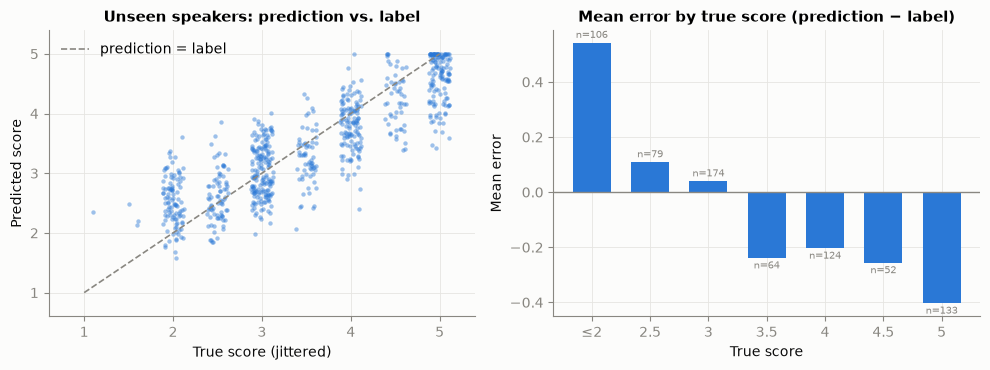

In [12]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
ax = axes[0]
ax.scatter(
    y + rng.uniform(-0.12, 0.12, len(y)),
    final_oof,
    s=10,
    alpha=0.45,
    color=BLUE,
    linewidths=0,
)
ax.plot(
    [1, 5],
    [1, 5],
    color=MUTED,
    linewidth=1.2,
    linestyle="--",
    label="prediction = label",
)
ax.legend(frameon=False, loc="upper left")
ax.set(
    title="Unseen speakers: prediction vs. label",
    xlabel="True score (jittered)",
    ylabel="Predicted score",
    xlim=(0.6, 5.4),
    ylim=(0.6, 5.4),
)
bands = pd.cut(
    y,
    [0, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.0],
    labels=["≤2", "2.5", "3", "3.5", "4", "4.5", "5"],
)
by_band = (
    pd.DataFrame({"band": bands, "residual": final_oof - y})
    .groupby("band", observed=True)["residual"]
    .agg(["mean", "size"])
)
ax = axes[1]
bars = ax.bar(by_band.index.astype(str), by_band["mean"], color=BLUE, width=0.65)
ax.bar_label(
    bars, labels=[f"n={n}" for n in by_band["size"]], padding=2, fontsize=7, color=MUTED
)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set(
    title="Mean error by true score (prediction − label)",
    xlabel="True score",
    ylabel="Mean error",
)
plt.tight_layout()
plt.show()

The model still pulls extreme scores towards the middle: the weakest speakers are scored too
high and the strongest too low, even after calibration. With only four training clips below 2,
the bottom of the scale cannot be learned well.

## 10. How we got here (experiment log)

Public leaderboard scores (lower is better) for each submitted model, with the validation
figure available at the time. Up to E024, validation used random folds; its numbers kept
improving while the leaderboard reacted less and less, which is what led to the speaker and
test-mix analysis. The validation columns use different yardsticks and are not comparable
across columns: E026/E027 were measured on 255 rows whose speaker was absent from the random
folds, E028 on all 732 rows. Like for like, E028 improves on E027 by about 0.004.

,submission,random-fold RMSE,unseen-speaker RMSE,public LB
0,"E008 DeBERTa-base, canonical transcript",0.6198,NaN,0.3925
1,E014 multi-seed base and large,0.5732,NaN,0.3894
2,"E015 + verbatim transcripts (dual, v2)",0.5545,NaN,0.3778
3,E020 + wav2vec2 CTC transcripts,0.5466,NaN,0.3712
4,"E022 + WavLM audio (RBF-SVR, random folds)",0.5073,NaN,0.3605
5,E024 + calibration,0.4942,NaN,0.3501
6,"E026 unseen-speaker validation, Ridge audio",NaN,0.5490,0.3448
7,E027 + Voxtral,NaN,0.5440,0.3362
8,"E028 speaker-grouped text, Voxtral views (final)",NaN,0.5356,0.3341


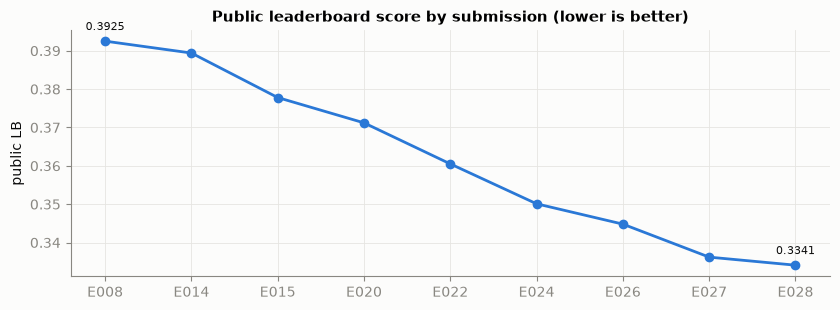

In [13]:
log = pd.DataFrame(
    [
        ("E008 DeBERTa-base, canonical transcript", 0.6198, np.nan, 0.3925),
        ("E014 multi-seed base and large", 0.5732, np.nan, 0.3894),
        ("E015 + verbatim transcripts (dual, v2)", 0.5545, np.nan, 0.3778),
        ("E020 + wav2vec2 CTC transcripts", 0.5466, np.nan, 0.3712),
        ("E022 + WavLM audio (RBF-SVR, random folds)", 0.5073, np.nan, 0.3605),
        ("E024 + calibration", 0.4942, np.nan, 0.3501),
        ("E026 unseen-speaker validation, Ridge audio", np.nan, 0.549, 0.3448),
        ("E027 + Voxtral", np.nan, 0.544, 0.3362),
        (
            "E028 speaker-grouped text, Voxtral views (final)",
            np.nan,
            honest_rmse,
            0.3341,
        ),
    ],
    columns=["submission", "random-fold RMSE", "unseen-speaker RMSE", "public LB"],
)
display(log.round(4))

fig, ax = plt.subplots(figsize=(8.5, 3.2))
x = np.arange(len(log))
ax.plot(x, log["public LB"], color=BLUE, linewidth=2, marker="o", markersize=6)
ax.set_xticks(x, [name.split(" ")[0] for name in log["submission"]])
for i in (0, len(log) - 1):
    ax.annotate(
        f"{log['public LB'][i]:.4f}",
        (i, log["public LB"][i]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8,
        color=INK,
    )
ax.set(
    title="Public leaderboard score by submission (lower is better)", ylabel="public LB"
)
plt.tight_layout()
plt.show()

**Tried and rejected:**

| Experiment | Result | Why rejected |
| --- | --- | --- |
| Handcrafted acoustic features + stacking (E006a, E012a, E013) | ≤0.005 gain | did not transfer to the leaderboard |
| CORAL ordinal head (E007) | no gain | |
| Qwen2.5-7B QLoRA regressor (E016) | RMSE 0.710 | weaker than DeBERTa |
| GEC edit rate, LLM rubric judge, fluency features (E017, E019) | channel RMSE 0.72–0.74 on unseen speakers | zero blend weight, also when re-tested with unseen-speaker validation |
| RoBERTa-large as a 7th text group (E021) | 0.5443 vs 0.5466 | only 3 of 5 folds improved |
| WavLM-large + Whisper all-layer means, RBF-SVR, random folds (E023) | random-fold 0.481, LB 0.3649 | learned voices; worse publicly |
| Per-duration blend on random-fold predictions (E025) | LB 0.3499 | tie with E024; validation was still speaker-leaky |
| Voxtral final-token states | RMSE ≈ 0.60 | worse than its audio-token states (0.56) |
| Test-time audio normalization | worse under grouped folds | batch differences partly reflect real ability |
| Tree / Ridge stackers; rounding to the 0.5 grid | worse | too little data; rounding hurt every fold |
| Using a matched training speaker's score for test clips | −0.09 RMSE on matched clips | speaker recognition, not grammar scoring; left out on purpose |

## 11. Submission

The three channels' test predictions (text: fold-averaged speaker-grouped models; audio and
Voxtral: Ridge refitted on all 732 rows) are blended with the weights above, calibrated with
the line fitted on all unseen-speaker predictions, and clipped to [1, 5]. The file is checked
against the submission scored on the public leaderboard (0.3341).

wrote /Volumes/Transcend/Kaggle Competition/grammar-scoring/artifacts/final_e015/submission.csv (216 rows)
matches the scored E028 submission: True


,count,mean,std,min,25%,50%,75%,max
label,216.0,3.255,0.859,1.538,2.576,3.133,3.748,5.0


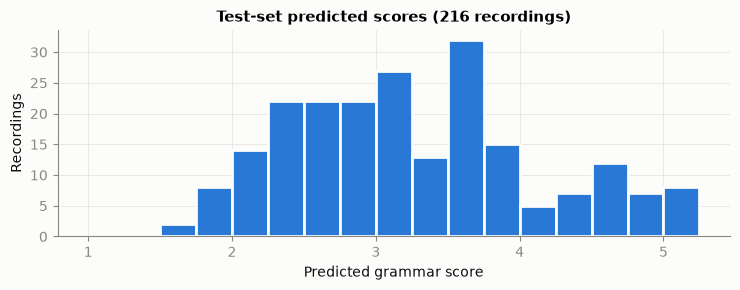

In [14]:
submission = pd.DataFrame(
    {
        "filename": test_pred["filename"],
        "label": apply_calibration(test_channels @ blend, line),
    }
)
assert submission["filename"].tolist() == test["filename"].tolist()
assert len(submission) == 216 and submission["filename"].is_unique
assert np.isfinite(submission["label"]).all()
path = OUTPUT_DIR / "submission.csv"
submission.to_csv(path, index=False)
print(f"wrote {path} ({len(submission)} rows)")
scored = FINAL_DIR / "e028" / "submission.csv"
if scored.exists():
    print(
        "matches the scored E028 submission:",
        np.allclose(
            pd.read_csv(scored)["label"], submission["label"], rtol=0, atol=1e-6
        ),
    )
display(submission.describe().round(3).T)

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.hist(
    submission["label"],
    bins=np.arange(1.0, 5.26, 0.25),
    color=BLUE,
    edgecolor=SURFACE,
    linewidth=2,
)
ax.set(
    title="Test-set predicted scores (216 recordings)",
    xlabel="Predicted grammar score",
    ylabel="Recordings",
)
plt.tight_layout()
plt.show()

## 12. Limitations and next steps

* **Small data.** 732 clips from 377 speakers; the nested estimate still carries noise of
  about ±0.01, and the test-like subset (short clips from single-clip speakers) has only about 130
  training clips.
* **Speaker grouping is approximate.** It relies on a voice-similarity threshold; a few
  speakers may be split or merged.
* **Short, single-speaker clips are the hard case** and the majority of the test set; errors
  there are the main remaining cost.
* **ASR dependence.** Scores inherit recognition errors; verbatim decoding is prompt-driven.
* **Shrinkage and coarse labels.** Extreme scores are pulled towards the middle, and labels
  are human opinions on a 0.5 grid.
* **Zero-label block.** The 37 clips labelled 0 are excluded as a noisy batch (a CTC model
  hears no speech in about half of them); no test clip looks like them.

## 13. Reproducing

```sh
# transcripts and text models (GPU; one run per seed, speaker-grouped folds)
python scripts/transcribe_verbatim.py --data-dir <Dataset_Final> --output-dir <out> --variant v1
python scripts/transcribe_ctc.py --data-dir <Dataset_Final> --output-dir <ctc_out>
python scripts/run_e014_finetune.py --data-dir <Dataset_Final> --transcript-dir <canonical> \
    --alt-transcript-dir <verbatim_v1> --folds-csv train_folds_grouped.csv \
    --model-name microsoft/deberta-v3-large --learning-rate 1e-5 --layer-decay 0.9 \
    --gradient-checkpointing --seeds 42 7 2024 --output-dir <runs>/large_dual
# frozen audio features (GPU, once)
python scripts/extract_audio_layers.py --data-dir <Dataset_Final> --output-dir <layers>
python -m grammar_scoring.features.speaker_voxtral --data-dir <Dataset_Final> \
    --output-dir <out> --what speaker voxtral
python -m grammar_scoring.features.speaker_voxtral --data-dir <Dataset_Final> \
    --output-dir <out> --what voxtral --question errors --question-first --layers 12 13 14
# unseen-speaker evaluation, blend, calibration and submission (CPU)
python scripts/run_e028_grouped_blend.py --runs-dir <runs> --groups large_dual base_dual \
    large_v2 base_v2 large_ctc base_ctc --features <features.npz> --output-dir <out>
```